# XAI Faithfulness Analysis — CppSATD
Visualize explanation results from the best model (`deberta-base + unixcoder-base-nine`, cross-attention, Phase 4).

**Data:** `results/explain/500_samples/`  
**Metrics:**
- `delta_del` (Comprehensiveness): prob drop after masking top-k tokens — higher = more faithful  
- `p_suf` (Sufficiency probability): prob when keeping only top-k tokens  
- `delta_suf` = p_orig − p_suf: lower = top-k tokens alone are sufficient

## 1. Import Libraries

In [31]:
import json
import pathlib
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA_DIR = pathlib.Path("../results/explain/test_samples")
LABELS   = ["Non-SATD", "Design", "Requirement", "Defect", "Test", "Documentation"]
K_VALUES = [5, 10, 20]
LABEL_COLORS = {
    "Non-SATD":     "#4C72B0",
    "Design":       "#DD8452",
    "Requirement":  "#55A868",
    "Defect":       "#C44E52",
    "Test":         "#8172B3",
    "Documentation":"#937860",
}
print("Libraries loaded.")

Libraries loaded.


## 2. Load Explanation Data

In [32]:
# ── Load faithfulness_summary.json ───────────────────────────────────────────
with open(DATA_DIR / "faithfulness_summary.json") as f:
    faith_summary = json.load(f)

# ── Load per_sample_explanations.jsonl ───────────────────────────────────────
samples = []
with open(DATA_DIR / "per_sample_explanations.jsonl") as f:
    for line in f:
        samples.append(json.loads(line))

# Flatten to DataFrame
rows = []
for s in samples:
    row = {
        "comment_id": s["comment_id"],
        "true_label": s["true_label"],
        "pred_label": s["pred_label"],
        "pred_prob":  s["pred_prob"],
        "correct":    s["true_label"] == s["pred_label"],
        "n_comment_tokens": len(s["top_comment_tokens"]),
        "n_code_lines":     len(s["top_code_lines"]),
    }
    for k in K_VALUES:
        km = s["k_metrics"].get(str(k), {})
        row[f"delta_del_{k}"]  = km.get("delta_del", 0.0)
        row[f"p_suf_{k}"]      = km.get("p_suf",     0.0)
        row[f"delta_suf_{k}"]  = km.get("delta_suf",  0.0)
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Samples: {len(df)}  |  Classes: {df['true_label'].nunique()}")
df.head(3)

Samples: 3905  |  Classes: 6


,comment_id,true_label,pred_label,pred_prob,correct,n_comment_tokens,n_code_lines,delta_del_5,p_suf_5,delta_suf_5,delta_del_10,p_suf_10,delta_suf_10,delta_del_20,p_suf_20,delta_suf_20
0,5968,Design,Design,0.998389,True,10,5,0.000108,0.000075,0.998314,0.998236,0.290191,0.708198,0.998373,0.999564,-0.001174
1,9033,Design,Design,0.995219,True,10,6,0.797212,0.000349,0.994870,0.993060,0.702108,0.293112,0.994971,0.745372,0.249847
2,9689,Requirement,Requirement,0.959698,True,10,6,-0.037353,0.000107,0.959591,0.959620,0.973430,-0.013731,0.959648,0.960762,-0.001064


## 3. Overall Faithfulness Metrics by k

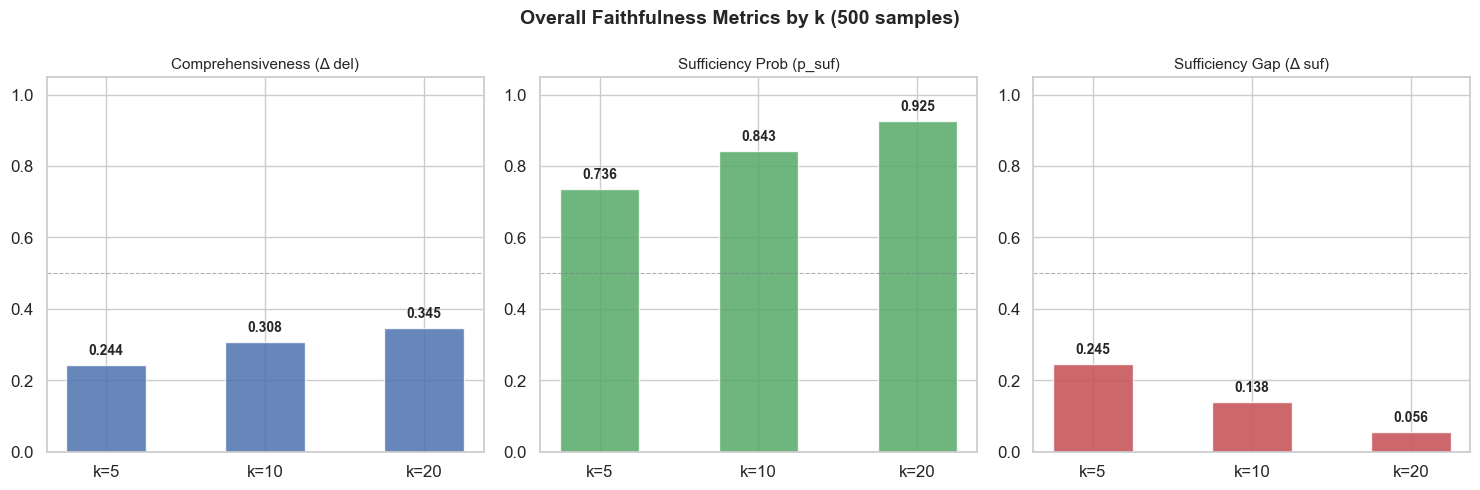

Saved: chart_overall_metrics.pdf


In [33]:
overall = faith_summary["overall"]
ks      = [str(k) for k in K_VALUES]
metrics = ["mean_delta_del", "mean_p_suf", "mean_delta_suf"]
labels_m = ["Comprehensiveness (Δ del)", "Sufficiency Prob (p_suf)", "Sufficiency Gap (Δ suf)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Overall Faithfulness Metrics by k (500 samples)", fontsize=14, fontweight="bold")

colors = ["#4C72B0", "#55A868", "#C44E52"]
for ax, metric, label, color in zip(axes, metrics, labels_m, colors):
    vals = [overall[k][metric] for k in ks]
    bars = ax.bar([f"k={k}" for k in ks], vals, color=color, alpha=0.85, width=0.5)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_overall_metrics.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_overall_metrics.pdf")

## 4. Per-Class Faithfulness Heatmap

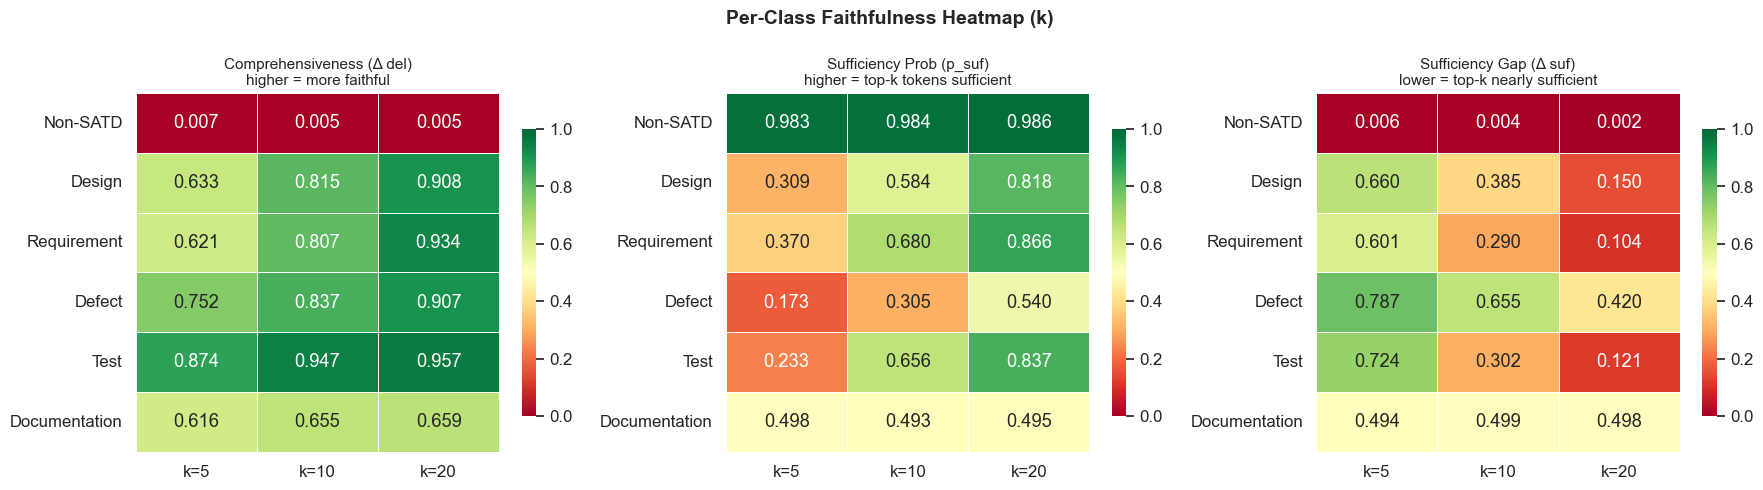

Saved: chart_perclass_heatmap.pdf


In [34]:
per_class = faith_summary["per_class"]
cls_order = [c for c in LABELS if c in per_class]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Per-Class Faithfulness Heatmap (k)", fontsize=14, fontweight="bold")

def make_heatmap(ax, metric, title):
    data = []
    for cls in cls_order:
        row = [per_class[cls][str(k)][metric] for k in K_VALUES]
        data.append(row)
    heat_df = pd.DataFrame(data, index=cls_order, columns=[f"k={k}" for k in K_VALUES])
    sns.heatmap(heat_df, ax=ax, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("")

make_heatmap(axes[0], "mean_delta_del", "Comprehensiveness (Δ del)\nhigher = more faithful")
make_heatmap(axes[1], "mean_p_suf",     "Sufficiency Prob (p_suf)\nhigher = top-k tokens sufficient")
make_heatmap(axes[2], "mean_delta_suf", "Sufficiency Gap (Δ suf)\nlower = top-k nearly sufficient")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_perclass_heatmap.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_perclass_heatmap.pdf")

## 5. Per-Sample Faithfulness Distribution (k=10)

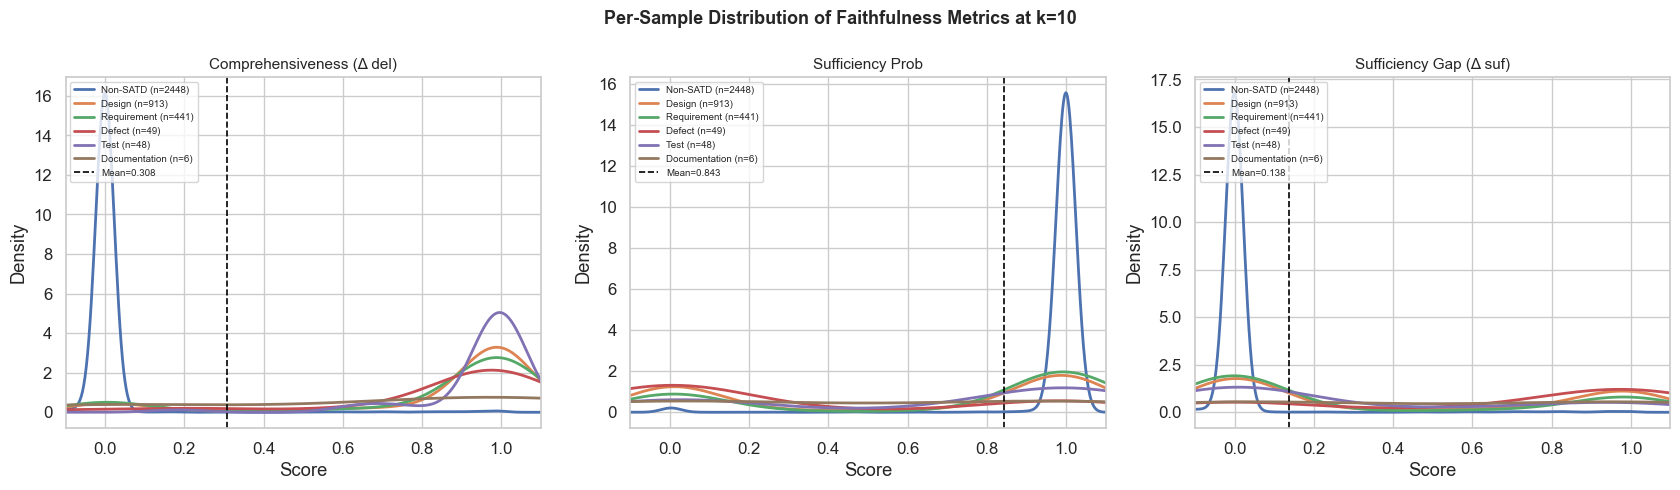

Saved: chart_distribution_k10.pdf


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Per-Sample Distribution of Faithfulness Metrics at k=10", fontsize=13, fontweight="bold")

metric_cols = {"delta_del_10": "Comprehensiveness (Δ del)",
               "p_suf_10":     "Sufficiency Prob",
               "delta_suf_10": "Sufficiency Gap (Δ suf)"}

for ax, (col, title) in zip(axes, metric_cols.items()):
    for label in cls_order:
        sub = df[df["true_label"] == label][col]
        if len(sub) > 1:
            sub.plot.kde(ax=ax, label=f"{label} (n={len(sub)})",
                         color=LABEL_COLORS.get(label), linewidth=2)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.2, label=f"Mean={mean_val:.3f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-0.1, 1.1)
    ax.set_xlabel("Score")
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_distribution_k10.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_distribution_k10.pdf")

## 6. Top & Bottom 10 Samples by Comprehensiveness (k=10)

In [36]:
# Build sample-level lookup for tokens/code lines
sample_map = {s["comment_id"]: s for s in samples}

top10    = df.nlargest(10, "delta_del_10")[["comment_id","true_label","pred_label","pred_prob","delta_del_10","p_suf_10"]].copy()
bottom10 = df.nsmallest(10, "delta_del_10")[["comment_id","true_label","pred_label","pred_prob","delta_del_10","p_suf_10"]].copy()

def add_tokens(sub_df):
    sub_df = sub_df.copy()
    sub_df["top_tokens"] = sub_df["comment_id"].apply(
        lambda cid: " | ".join(sample_map[cid]["top_comment_tokens"][:5])
        if cid in sample_map else ""
    )
    return sub_df

top10    = add_tokens(top10).reset_index(drop=True)
bottom10 = add_tokens(bottom10).reset_index(drop=True)

print("=== TOP 10 (most faithful explanations) ===")
display(top10.style.background_gradient(subset=["delta_del_10"], cmap="Greens").format(precision=4))
print("\n=== BOTTOM 10 (least faithful explanations) ===")
display(bottom10.style.background_gradient(subset=["delta_del_10"], cmap="Reds_r").format(precision=4))

=== TOP 10 (most faithful explanations) ===


,comment_id,true_label,pred_label,pred_prob,delta_del_10,p_suf_10,top_tokens
0,136627,Requirement,Requirement,1.0000,1.0000,0.9999,Ġnow | Ġfor | . | Ġsupported | Ġis
1,23773,Requirement,Requirement,1.0000,1.0000,1.0000,Ġdo | Ġnothing | should
2,63962,Test,Test,0.9999,0.9999,1.0000,Ġtest | Ġremove | Ġwhen | . | ):
3,52274,Test,Test,1.0000,0.9999,1.0000,: | me | Ġoptimize | . | Ġfor
4,112760,Test,Test,1.0000,0.9999,0.9999,Ġtest | ss | Ġbecause | t | odo
5,179835,Test,Test,0.9999,0.9999,0.9999,Ġtests | Ġadd | Ġfor | ): | Ġall
6,54385,Requirement,Requirement,0.9999,0.9999,1.0000,: | me | Ġshould | fix | Ġto
7,95923,Requirement,Requirement,0.9999,0.9999,0.9999,ing | proof | . | Ġin | Ġthe
8,2732,Requirement,Requirement,1.0000,0.9999,0.9999,] | Ġ/ | xx | [
9,23403,Requirement,Requirement,1.0000,0.9999,0.0557,Ġcurrently | Ġnot | Ġhandle | Ġfuture | Ġonly



=== BOTTOM 10 (least faithful explanations) ===


,comment_id,true_label,pred_label,pred_prob,delta_del_10,p_suf_10,top_tokens
0,247286,Non-SATD,Non-SATD,0.4247,-0.5733,0.9999,". | , | Ġimplemented | Ġthis | Ġis"
1,66637,Non-SATD,Non-SATD,0.4553,-0.5107,0.9998,: | : | Ġfollowing | . | the
2,29216,Non-SATD,Non-SATD,0.4911,-0.5087,0.4555,monitor | ave | ? | Ġpowers | Ġtrying
3,13708,Non-SATD,Non-SATD,0.4040,-0.5025,0.9992,". | Ġdifferent | if | , | Ġin"
4,11207,Design,Non-SATD,0.4734,-0.4867,0.9998,=== | === | this | === | Ġthe
5,246713,Requirement,Non-SATD,0.5248,-0.4663,0.9995,hel | . | Ġthe | Ġfunction | Ġif
6,83454,Design,Non-SATD,0.5368,-0.4630,0.4412,? | array | limit | get | dest
7,49732,Non-SATD,Non-SATD,0.4641,-0.4425,0.9998,=== | === | Ġthe | === | Ġis
8,6662,Non-SATD,Non-SATD,0.5575,-0.4420,0.4756,? | instance
9,69527,Requirement,Non-SATD,0.5565,-0.4401,1.0000,Ġincluding | Ġfuture | . | : | fill


## 7. Prediction Accuracy & Confidence by Class

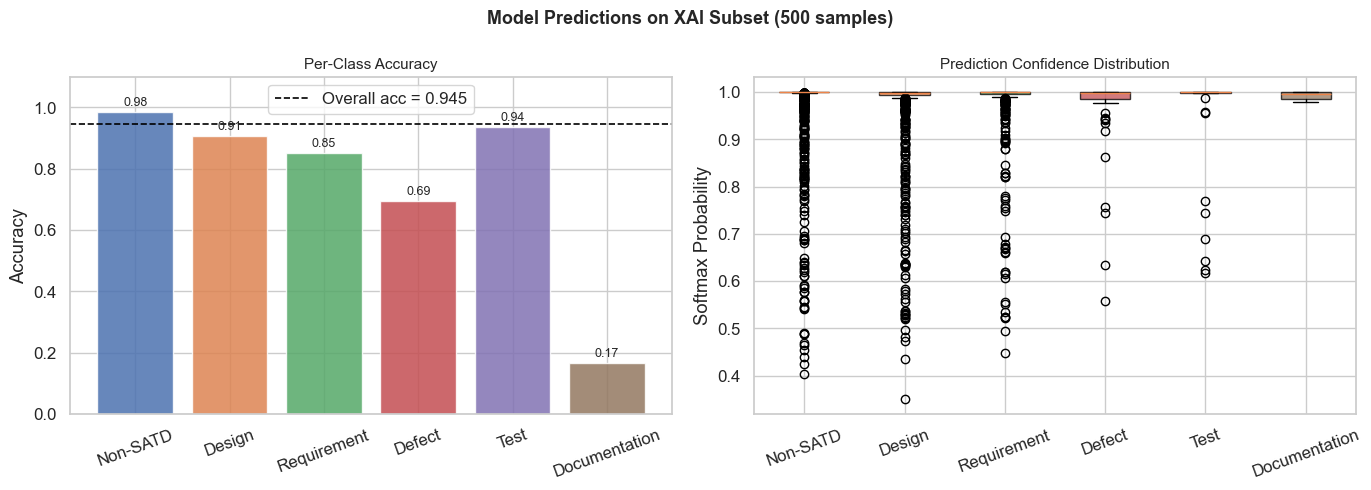

Saved: chart_accuracy_confidence.pdf


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Predictions on XAI Subset (500 samples)", fontsize=13, fontweight="bold")

# Left: accuracy per class (bar)
acc_by_class = df.groupby("true_label")["correct"].mean().reindex(cls_order)
colors_bar = [LABEL_COLORS[c] for c in acc_by_class.index]
axes[0].bar(acc_by_class.index, acc_by_class.values, color=colors_bar, alpha=0.85)
axes[0].axhline(df["correct"].mean(), color="black", linestyle="--", linewidth=1.2,
                label=f"Overall acc = {df['correct'].mean():.3f}")
axes[0].set_title("Per-Class Accuracy", fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=20)
for i, (cls, v) in enumerate(acc_by_class.items()):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
axes[0].legend()

# Right: prediction confidence boxplot per class (sorted by median)
data_box = [df[df["true_label"] == cls]["pred_prob"].values for cls in cls_order]
bp = axes[1].boxplot(data_box, labels=cls_order, patch_artist=True, notch=False)
for patch, cls in zip(bp["boxes"], cls_order):
    patch.set_facecolor(LABEL_COLORS[cls])
    patch.set_alpha(0.75)
axes[1].set_title("Prediction Confidence Distribution", fontsize=11)
axes[1].set_ylabel("Softmax Probability")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_accuracy_confidence.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_accuracy_confidence.pdf")

## 8. Top Comment Tokens Frequency (by Class)

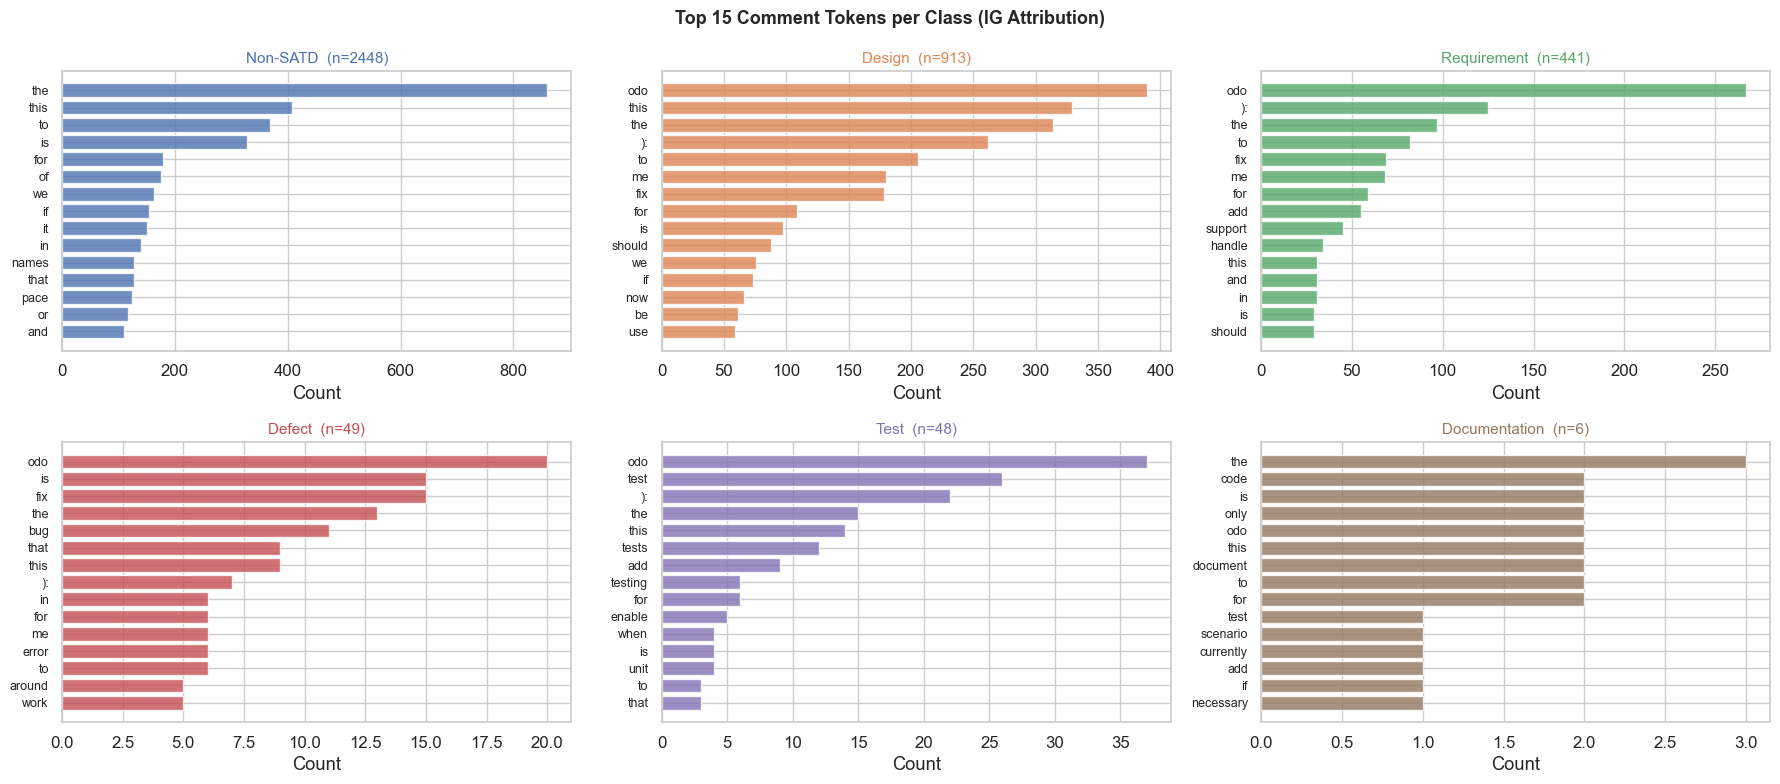

Saved: chart_top_tokens.pdf


In [38]:
def clean_token(t):
    """Strip RoBERTa Ġ prefix and lowercase."""
    return t.replace("Ġ", "").replace("Ċ", "").strip().lower()

# Build per-class token counters
class_tokens = {cls: Counter() for cls in cls_order}
for s in samples:
    cls = s["true_label"]
    if cls in class_tokens:
        for tok in s["top_comment_tokens"]:
            tok_clean = clean_token(tok)
            if tok_clean and len(tok_clean) > 1:
                class_tokens[cls][tok_clean] += 1

n_classes = len(cls_order)
ncols = 3
nrows = (n_classes + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()
fig.suptitle("Top 15 Comment Tokens per Class (IG Attribution)", fontsize=13, fontweight="bold")

for ax, cls in zip(axes, cls_order):
    mc = class_tokens[cls].most_common(15)
    if not mc:
        ax.axis("off")
        continue
    tokens, counts = zip(*mc)
    ax.barh(range(len(tokens)), counts[::-1],
            color=LABEL_COLORS.get(cls, "#888"), alpha=0.8)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(list(reversed(tokens)), fontsize=9)
    n_cls = df[df["true_label"] == cls].shape[0]
    ax.set_title(f"{cls}  (n={n_cls})", fontsize=11, color=LABEL_COLORS.get(cls, "#333"))
    ax.set_xlabel("Count")

for ax in axes[n_classes:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_top_tokens.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_top_tokens.pdf")

## 9. Comprehensiveness vs Sufficiency Scatter (k=10)

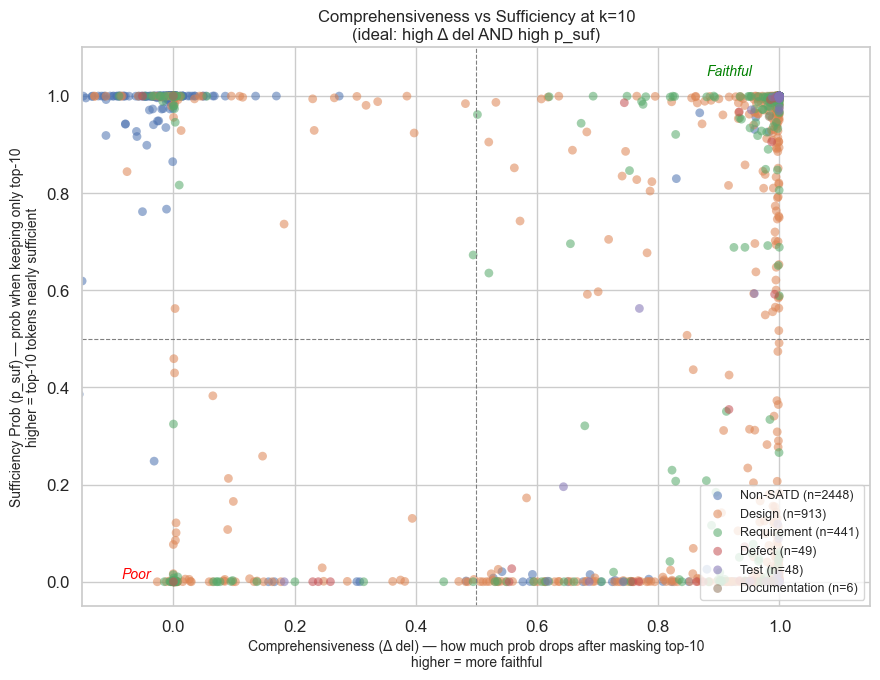

Saved: chart_scatter_comp_suf.pdf


In [39]:
fig, ax = plt.subplots(figsize=(9, 7))
for cls in cls_order:
    sub = df[df["true_label"] == cls]
    ax.scatter(sub["delta_del_10"], sub["p_suf_10"],
               label=f"{cls} (n={len(sub)})",
               color=LABEL_COLORS.get(cls), alpha=0.55, s=40,
               edgecolors="none")

ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Comprehensiveness (Δ del) — how much prob drops after masking top-10\nhigher = more faithful", fontsize=10)
ax.set_ylabel("Sufficiency Prob (p_suf) — prob when keeping only top-10\nhigher = top-10 tokens nearly sufficient", fontsize=10)
ax.set_title("Comprehensiveness vs Sufficiency at k=10\n(ideal: high Δ del AND high p_suf)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.05, 1.1)

ax.text(0.85, 0.95, "Faithful", transform=ax.transAxes, ha="right",
        fontsize=10, color="green", fontstyle="italic")
ax.text(0.05, 0.05, "Poor", transform=ax.transAxes, ha="left",
        fontsize=10, color="red", fontstyle="italic")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_scatter_comp_suf.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_scatter_comp_suf.pdf")

## 10. Summary Table — All Metrics

In [40]:
summary_rows = []
for cls in ["__overall__"] + cls_order:
    src = faith_summary["overall"] if cls == "__overall__" else faith_summary["per_class"].get(cls, {})
    if not src:
        continue
    row = {"Class": "Overall" if cls == "__overall__" else cls}
    row["n"] = src.get(str(K_VALUES[0]), {}).get("n_samples", "—")
    for k in K_VALUES:
        km = src.get(str(k), {})
        row[f"Δdel k={k}"]  = f"{km.get('mean_delta_del', 0):.4f}"
        row[f"p_suf k={k}"]  = f"{km.get('mean_p_suf', 0):.4f}"
        row[f"Δsuf k={k}"]  = f"{km.get('mean_delta_suf', 0):.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Class")
display(summary_df.style
    .background_gradient(subset=[c for c in summary_df.columns if "Δdel" in c], cmap="Greens")
    .background_gradient(subset=[c for c in summary_df.columns if "p_suf" in c], cmap="Blues")
    .background_gradient(subset=[c for c in summary_df.columns if "Δsuf" in c], cmap="Reds_r")
    .set_caption("Faithfulness Summary — all k values")
    .format(lambda x: x if isinstance(x, str) else f"{x}")
)

print("\nAll charts saved to:", DATA_DIR)

,n,Δdel k=5,p_suf k=5,Δsuf k=5,Δdel k=10,p_suf k=10,Δsuf k=10,Δdel k=20,p_suf k=20,Δsuf k=20
Class,,,,,,,,,,
Overall,3905,0.2437,0.7358,0.2451,0.3081,0.8426,0.1383,0.3454,0.9249,0.0559
Non-SATD,2448,0.0069,0.9826,0.0056,0.0053,0.9837,0.0044,0.0055,0.9858,0.0024
Design,913,0.6335,0.3091,0.6596,0.8147,0.5837,0.3849,0.9077,0.8184,0.1503
Requirement,441,0.6206,0.3697,0.6005,0.8071,0.6799,0.2903,0.9345,0.8661,0.1041
Defect,49,0.7521,0.1726,0.7873,0.8369,0.3045,0.6554,0.9071,0.5403,0.4197
Test,48,0.8745,0.2334,0.7245,0.9466,0.6557,0.3022,0.9574,0.8370,0.1209
Documentation,6,0.6161,0.4981,0.4942,0.6552,0.4930,0.4993,0.6586,0.4946,0.4977



All charts saved to: ..\results\explain\test_samples


## 11. Comment vs Code Evidence Count per Class

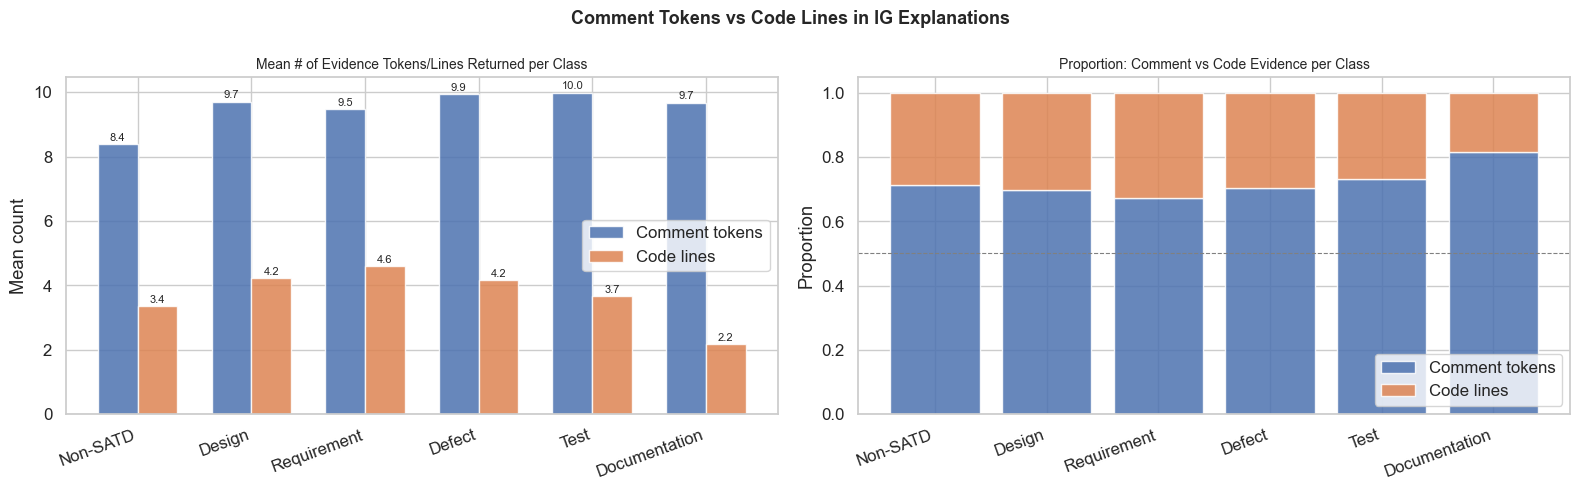

Saved: chart_comment_vs_code_count.pdf


In [41]:
# Average number of top comment tokens vs top code lines per class
agg = df.groupby("true_label")[["n_comment_tokens", "n_code_lines"]].mean().reindex(cls_order)

x = np.arange(len(cls_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Comment Tokens vs Code Lines in IG Explanations", fontsize=13, fontweight="bold")

# Left: grouped bar — mean counts
ax = axes[0]
bars1 = ax.bar(x - width/2, agg["n_comment_tokens"], width, label="Comment tokens",
               color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + width/2, agg["n_code_lines"],     width, label="Code lines",
               color="#DD8452", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cls_order, rotation=20, ha="right")
ax.set_ylabel("Mean count")
ax.set_title("Mean # of Evidence Tokens/Lines Returned per Class", fontsize=10)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

# Right: stacked proportion — comment-to-code ratio
ax2 = axes[1]
total = agg["n_comment_tokens"] + agg["n_code_lines"]
ratio_c = agg["n_comment_tokens"] / total.replace(0, np.nan)
ratio_k = agg["n_code_lines"]     / total.replace(0, np.nan)
ax2.bar(cls_order, ratio_c, color="#4C72B0", alpha=0.85, label="Comment tokens")
ax2.bar(cls_order, ratio_k, bottom=ratio_c, color="#DD8452", alpha=0.85, label="Code lines")
ax2.set_ylabel("Proportion")
ax2.set_title("Proportion: Comment vs Code Evidence per Class", fontsize=10)
ax2.set_xticklabels(cls_order, rotation=20, ha="right")
ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_comment_vs_code_count.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_comment_vs_code_count.pdf")

## 12. Top Code Keywords per Class (IG Attribution)

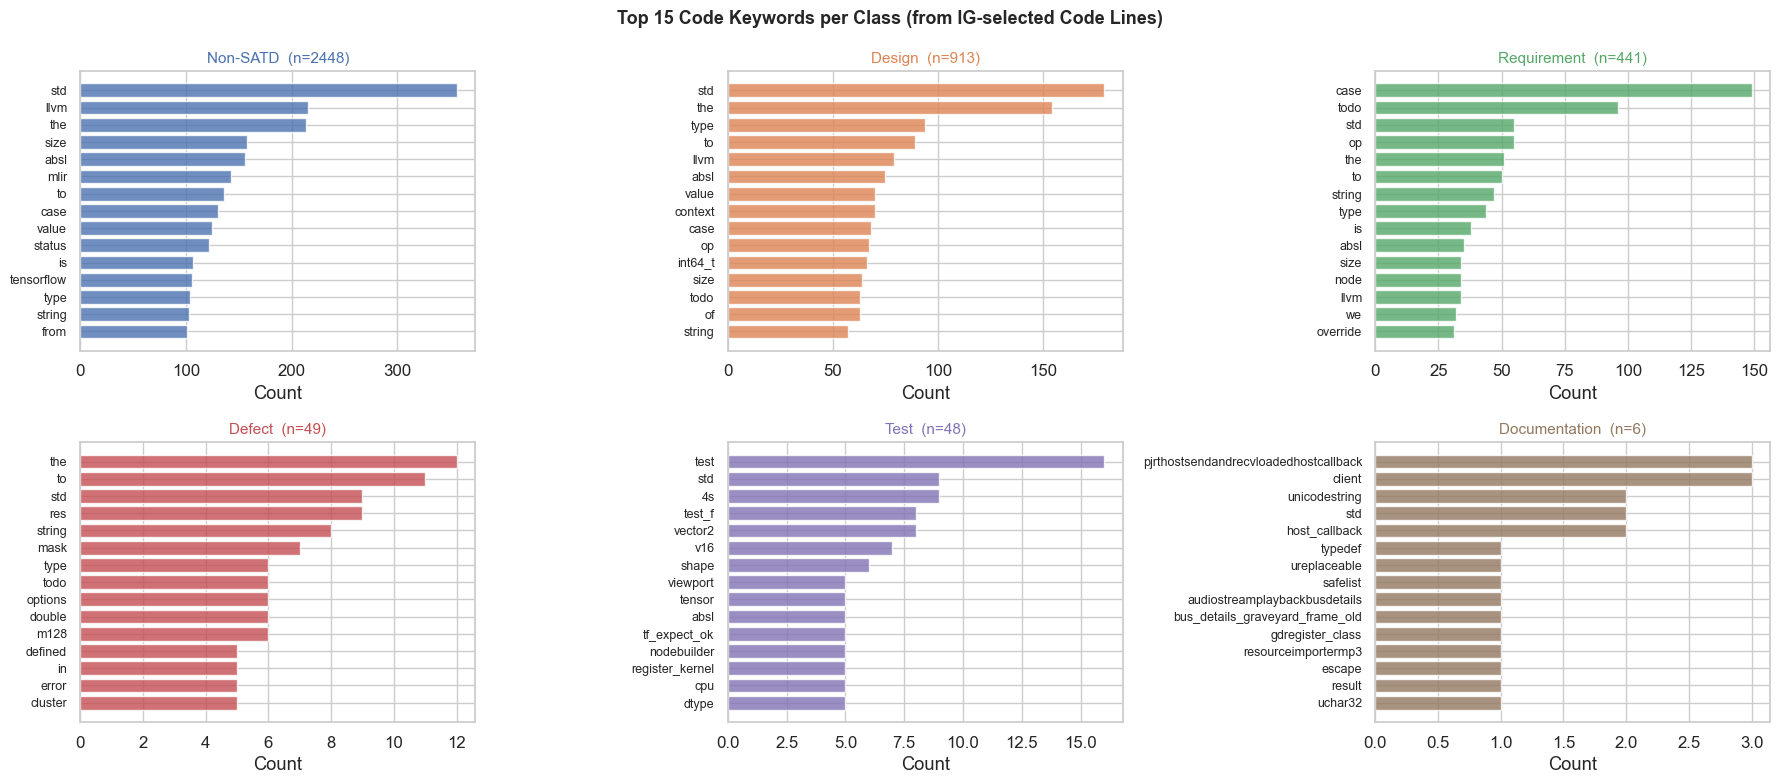

Saved: chart_top_code_keywords.pdf


In [42]:
import re

# C++ stopwords to filter meaningless keywords
CPP_STOP = {
    "int", "void", "return", "if", "else", "for", "while", "do", "break",
    "continue", "new", "delete", "const", "static", "auto", "bool", "true",
    "false", "null", "nullptr", "this", "class", "public", "private",
    "protected", "namespace", "include", "define", "ifndef", "endif",
    "ifdef", "0", "1", "2", "", " "
}

def extract_code_words(lines_list: list) -> list:
    """Extract word tokens from top_code_lines[*].text, filter stopwords."""
    words = []
    for entry in lines_list:
        text = entry.get("text", "") if isinstance(entry, dict) else str(entry)
        # split on non-alphanumeric, keep identifiers/keywords
        tokens = re.split(r"[^a-zA-Z0-9_]+", text)
        for t in tokens:
            t = t.strip().lower()
            if t and len(t) > 1 and t not in CPP_STOP:
                words.append(t)
    return words

# Build per-class code keyword counters
code_keywords = {cls: Counter() for cls in cls_order}
for s in samples:
    cls = s["true_label"]
    if cls in code_keywords:
        for w in extract_code_words(s["top_code_lines"]):
            code_keywords[cls][w] += 1

n_classes = len(cls_order)
ncols = 3
nrows = (n_classes + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()
fig.suptitle("Top 15 Code Keywords per Class (from IG-selected Code Lines)", fontsize=13, fontweight="bold")

for ax, cls in zip(axes, cls_order):
    mc = code_keywords[cls].most_common(15)
    if not mc:
        ax.axis("off")
        continue
    tokens, counts = zip(*mc)
    ax.barh(range(len(tokens)), list(reversed(counts)),
            color=LABEL_COLORS.get(cls, "#888"), alpha=0.8)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(list(reversed(tokens)), fontsize=9)
    n_cls = df[df["true_label"] == cls].shape[0]
    ax.set_title(f"{cls}  (n={n_cls})", fontsize=11, color=LABEL_COLORS.get(cls, "#333"))
    ax.set_xlabel("Count")

for ax in axes[n_classes:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_top_code_keywords.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_top_code_keywords.pdf")

## 13. Attribution Source Balance — Comment vs Code per Sample

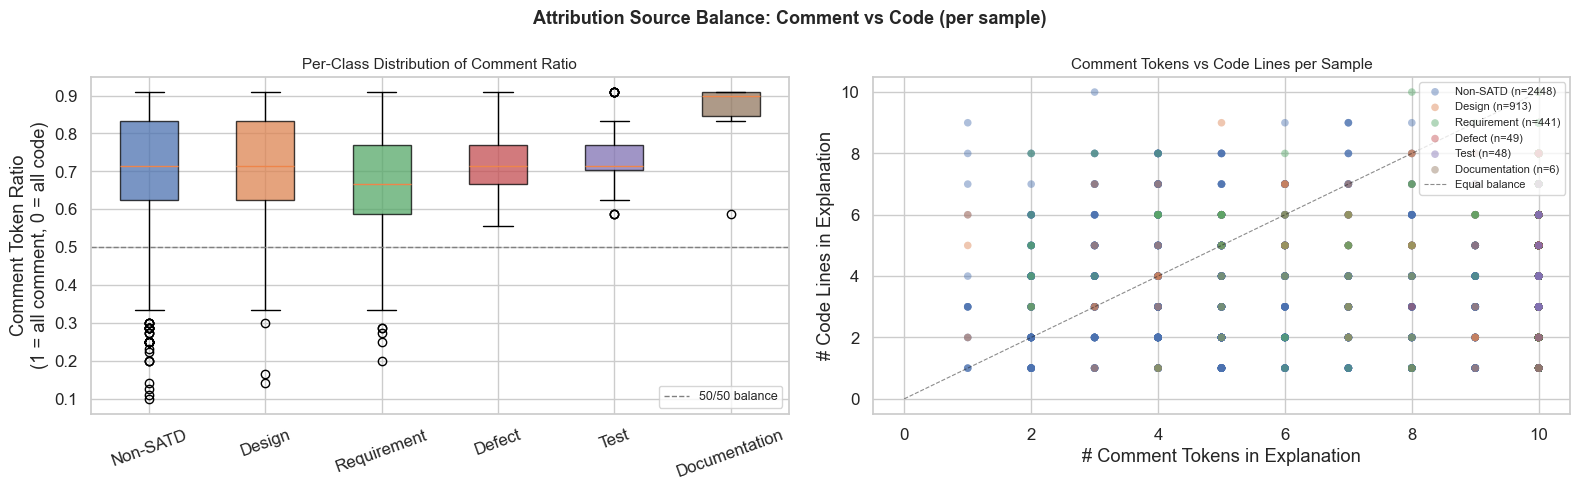

Saved: chart_attribution_balance.pdf

── Mean comment ratio per class ──
true_label
Non-SATD         0.713
Design           0.711
Requirement      0.684
Defect           0.719
Test             0.742
Documentation    0.840


In [43]:
# comment_ratio = n_comment_tokens / (n_comment_tokens + n_code_lines)
# ratio → 1.0 means explanation purely from comment; → 0.0 purely from code

df["total_evidence"] = df["n_comment_tokens"] + df["n_code_lines"]
df["comment_ratio"]  = df["n_comment_tokens"] / df["total_evidence"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Attribution Source Balance: Comment vs Code (per sample)", fontsize=13, fontweight="bold")

# Left: boxplot per class
data_box = [df[df["true_label"] == cls]["comment_ratio"].dropna().values for cls in cls_order]
bp = axes[0].boxplot(data_box, labels=cls_order, patch_artist=True, notch=False)
for patch, cls in zip(bp["boxes"], cls_order):
    patch.set_facecolor(LABEL_COLORS[cls])
    patch.set_alpha(0.75)
axes[0].axhline(0.5, color="grey", linestyle="--", linewidth=1.0,
                label="50/50 balance")
axes[0].set_ylabel("Comment Token Ratio\n(1 = all comment, 0 = all code)")
axes[0].set_title("Per-Class Distribution of Comment Ratio", fontsize=11)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=9)

# Right: scatter — comment count vs code lines, colored by class
for cls in cls_order:
    sub = df[df["true_label"] == cls]
    axes[1].scatter(sub["n_comment_tokens"], sub["n_code_lines"],
                    color=LABEL_COLORS.get(cls), alpha=0.45, s=30,
                    label=f"{cls} (n={len(sub)})", edgecolors="none")

# Reference line: equal balance
max_val = max(df["n_comment_tokens"].max(), df["n_code_lines"].max())
axes[1].plot([0, max_val], [0, max_val], "k--", linewidth=0.8, alpha=0.5, label="Equal balance")
axes[1].set_xlabel("# Comment Tokens in Explanation")
axes[1].set_ylabel("# Code Lines in Explanation")
axes[1].set_title("Comment Tokens vs Code Lines per Sample", fontsize=11)
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(DATA_DIR / "chart_attribution_balance.pdf", bbox_inches="tight")
plt.show()
print("Saved: chart_attribution_balance.pdf")

# -- quick summary stats
print("\n── Mean comment ratio per class ──")
print(df.groupby("true_label")["comment_ratio"].mean().reindex(cls_order).round(3).to_string())